In [368]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

In [369]:
print(sys.version)

3.12.5 (v3.12.5:ff3bc82f7c9, Aug  7 2024, 05:32:06) [Clang 13.0.0 (clang-1300.0.29.30)]


In [370]:
df = pd.read_csv("D600_Task_3_Dataset_1_Housing_Information.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    7000 non-null   int64  
 1   Price                 7000 non-null   float64
 2   SquareFootage         7000 non-null   float64
 3   NumBathrooms          7000 non-null   float64
 4   NumBedrooms           7000 non-null   int64  
 5   BackyardSpace         7000 non-null   float64
 6   CrimeRate             7000 non-null   float64
 7   SchoolRating          7000 non-null   float64
 8   AgeOfHome             7000 non-null   float64
 9   DistanceToCityCenter  7000 non-null   float64
 10  EmploymentRate        7000 non-null   float64
 11  PropertyTaxRate       7000 non-null   float64
 12  RenovationQuality     7000 non-null   float64
 13  LocalAmenities        7000 non-null   float64
 14  TransportAccess       7000 non-null   float64
 15  Fireplace            

## Keep Non-categorical Variables

In [371]:
df_cont = df.drop(columns=['ID','Fireplace', 'HouseColor', 'Garage', 'IsLuxury', 'Floors', 'Windows', 'NumBedrooms'])
df_cont.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 7000 non-null   float64
 1   SquareFootage         7000 non-null   float64
 2   NumBathrooms          7000 non-null   float64
 3   BackyardSpace         7000 non-null   float64
 4   CrimeRate             7000 non-null   float64
 5   SchoolRating          7000 non-null   float64
 6   AgeOfHome             7000 non-null   float64
 7   DistanceToCityCenter  7000 non-null   float64
 8   EmploymentRate        7000 non-null   float64
 9   PropertyTaxRate       7000 non-null   float64
 10  RenovationQuality     7000 non-null   float64
 11  LocalAmenities        7000 non-null   float64
 12  TransportAccess       7000 non-null   float64
 13  PreviousSalePrice     7000 non-null   float64
dtypes: float64(14)
memory usage: 765.8 KB


In [372]:
scaler = StandardScaler()
df_ind = df_cont.drop(columns=['Price'])
scaled = scaler.fit_transform(df_ind)
scaled_df = pd.DataFrame(df_ind, columns = df_ind.columns)
scaled_df.to_csv("Scaled_DF.csv")
scaled_df.head()

,SquareFootage,NumBathrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate,RenovationQuality,LocalAmenities,TransportAccess,PreviousSalePrice
0,566.62,1.000000,779.42,20.56,5.62,39.46,10.08,97.29,1.84,4.93,4.44,4.55,181861.54230
1,1472.34,1.000000,656.13,15.62,5.63,40.51,7.89,93.22,0.95,4.08,5.56,6.83,50042.59757
2,550.00,1.779354,754.57,12.47,9.20,48.38,23.74,96.60,1.87,4.26,8.07,8.48,48400.34440
3,941.81,2.035254,439.59,22.22,7.08,94.67,5.22,91.45,1.45,4.45,5.00,6.27,84594.12145
4,550.00,1.064644,353.03,8.28,5.93,16.80,43.13,86.50,1.26,3.36,5.46,6.99,22934.59654


In [373]:
df_cont.Price.describe()

count    7.000000e+03
mean     3.072820e+05
std      1.501734e+05
min      8.500000e+04
25%      1.921075e+05
50%      2.793230e+05
75%      3.918781e+05
max      1.046676e+06
Name: Price, dtype: float64

In [374]:
df_cont.Price.mode()

0       8.500000e+04
1       8.623883e+04
2       8.625022e+04
3       8.755343e+04
4       8.759270e+04
            ...     
6995    1.004324e+06
6996    1.021383e+06
6997    1.024519e+06
6998    1.045707e+06
6999    1.046676e+06
Name: Price, Length: 7000, dtype: float64

In [375]:
scaled_df.describe()

,SquareFootage,NumBathrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate,RenovationQuality,LocalAmenities,TransportAccess,PreviousSalePrice
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03
mean,1048.947459,2.131397,511.507029,31.226194,6.942923,46.797046,17.475337,93.711349,1.500437,5.003357,5.934579,5.983860,2.845094e+05
std,426.010482,0.952561,279.926549,18.025327,1.888148,31.779701,12.024985,4.505359,0.498591,1.970428,2.657930,1.953974,1.857340e+05
min,550.000000,1.000000,0.390000,0.030000,0.220000,0.010000,0.000000,72.050000,0.010000,0.010000,0.000000,0.010000,-8.356902e+03
25%,660.815000,1.290539,300.995000,17.390000,5.650000,20.755000,7.827500,90.620000,1.160000,3.660000,4.000000,4.680000,1.420140e+05
50%,996.320000,1.997774,495.965000,30.385000,7.010000,42.620000,15.625000,94.010000,1.490000,5.020000,6.040000,6.000000,2.621831e+05
75%,1342.292500,2.763997,704.012500,43.670000,8.360000,67.232500,25.222500,97.410000,1.840000,6.350000,8.050000,7.350000,3.961212e+05
max,2874.700000,5.807239,1631.360000,99.730000,10.000000,178.680000,65.200000,99.900000,3.360000,10.000000,10.000000,10.000000,1.296607e+06


In [376]:
print(scaled_df.mode().iloc[0])

SquareFootage            550.000000
NumBathrooms               1.000000
BackyardSpace            300.080000
CrimeRate                 34.010000
SchoolRating              10.000000
AgeOfHome                 18.180000
DistanceToCityCenter       8.290000
EmploymentRate            99.900000
PropertyTaxRate            1.430000
RenovationQuality         10.000000
LocalAmenities            10.000000
TransportAccess           10.000000
PreviousSalePrice      -8356.902464
Name: 0, dtype: float64


In [377]:
pca = PCA(n_components=None)

pcs = pca.fit_transform(scaled)

# Convert to DataFrame for readability
pcs_df = pd.DataFrame(pcs, columns=[f'PC{i+1}' for i in range(pcs.shape[1])])

# See the first few rows of the principal components
pcs_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,-1.247355,-0.157430,-1.544672,-0.264838,0.795306,0.840916,-0.589027,-0.470217,-0.461100,0.047834,-0.156871,0.665857,0.714871
1,-0.488469,0.512156,-0.896100,-1.282685,0.434805,-0.146777,0.916860,-1.502259,0.170017,-0.459943,0.436041,0.315028,-1.019016
2,-0.302746,1.927298,-1.656185,0.779187,0.635838,0.622797,0.020882,0.626531,0.089284,0.971784,0.343200,-0.727358,-0.324020
3,-0.790805,0.001600,-0.206688,0.084975,-0.239292,0.427451,1.376508,-0.300663,-1.298579,0.462984,0.351566,0.039468,-0.649151
4,-2.265972,1.171919,-0.570252,-0.667953,-0.421605,-0.236871,1.011888,0.995577,2.429658,0.534136,0.466190,0.349285,-0.117708


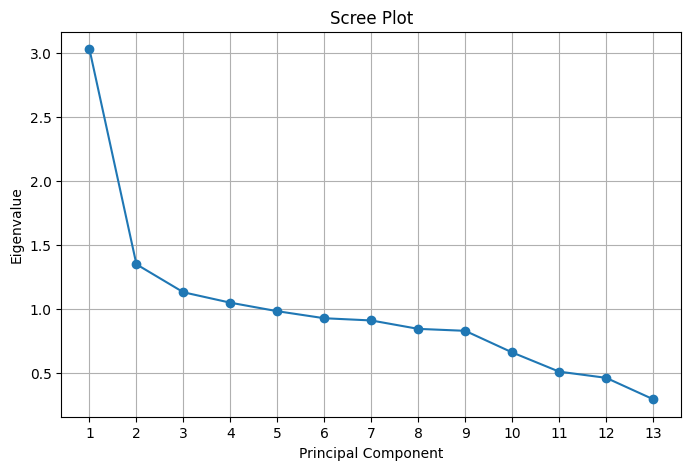

In [378]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_)+1),
         pca.explained_variance_,
         marker='o')

plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, len(pca.explained_variance_)+1))
plt.grid(True)
plt.show()

In [379]:
# Logic adapted from Scikit-learn
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

eigenvalues = pca.explained_variance_
kaiser_components = np.sum(eigenvalues > 1)

print("Eigenvalues:", eigenvalues)
print("Number of components to retain (Kaiser Rule):", kaiser_components)

Eigenvalues: [3.03147517 1.35072947 1.13224388 1.05071455 0.98422855 0.9293119
 0.91196049 0.84624217 0.83090577 0.66206516 0.51195829 0.46356013
 0.29646189]
Number of components to retain (Kaiser Rule): 4


In [380]:
print(f'Explained Variance:  {pca.explained_variance_}')
print(f'Explained Variance Ratio: {pca.explained_variance_ratio_}')

Explained Variance:  [3.03147517 1.35072947 1.13224388 1.05071455 0.98422855 0.9293119
 0.91196049 0.84624217 0.83090577 0.66206516 0.51195829 0.46356013
 0.29646189]
Explained Variance Ratio: [0.23315709 0.10388742 0.08708324 0.08081265 0.07569907 0.07147532
 0.07014079 0.06508625 0.0639067  0.05092081 0.03937578 0.03565338
 0.0228015 ]


Keep only 4 principal components

In [381]:
pca = PCA(n_components=4)

pcs = pca.fit_transform(scaled)

# Convert to DataFrame for readability
pcs_df = pd.DataFrame(pcs, columns=[f'PC{i+1}' for i in range(pcs.shape[1])])

# See the first few rows of the principal components
pcs_df.head()

,PC1,PC2,PC3,PC4
0,-1.247355,-0.157430,-1.544672,-0.264838
1,-0.488469,0.512156,-0.896100,-1.282685
2,-0.302746,1.927298,-1.656185,0.779187
3,-0.790805,0.001600,-0.206688,0.084975
4,-2.265972,1.171919,-0.570252,-0.667953


In [382]:
final_df = pd.concat([pcs_df, df.loc[pcs_df.index, "Price"]], axis=1)

Split the data

In [383]:
y= final_df['Price']
X= final_df.drop(columns = ['Price'])

# split the data into 80/20
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=1, 
                                   test_size=0.20)

In [384]:
print(X_train.shape)
X_train.to_csv("X_train.csv")

print(X_test.shape)
X_test.to_csv("X_test.csv")

print(y_train.shape)
y_train.to_csv("y_train.csv")

print(y_test.shape)
y_test.to_csv("y_test.csv")

(5600, 4)
(1400, 4)
(5600,)
(1400,)


Model Before Optimizing:

In [385]:
# Logic adapted from GeeksforGeeks (2025d)
# Source: https://www.geeksforgeeks.org/data-science/ordinary-least-squares-ols-using-statsmodels/
X_train_original = sm.add_constant(X_train)

lm = sm.OLS(y_train, X_train_original).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     2164.
Date:                Sun, 02 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:05:45   Log-Likelihood:                -72126.
No. Observations:                5600   AIC:                         1.443e+05
Df Residuals:                    5595   BIC:                         1.443e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.072e+05   1268.944    242.065      0.0

In [386]:
y_ori_train_pred = lm.predict(X_train_original)
MSE = mean_squared_error(y_train, y_ori_train_pred)
print(f"\nTrain MSE: {MSE:.2f}, Train RMSE: {np.sqrt(MSE):.2f}")


Train MSE: 9006864722.61, Train RMSE: 94904.50


In [387]:
X_test_original = sm.add_constant(X_test)

y_ori_test_pred = lm.predict(X_test_original)
MSE = mean_squared_error(y_test, y_ori_test_pred)
print(f"\nTestMSE: {MSE:.2f}, Test RMSE: {np.sqrt(MSE):.2f}")


TestMSE: 8607592655.33, Test RMSE: 92777.11


Backward Elimination:

In [388]:
# Logic adapted from GeeksforGeeks (2025h)
# Source: https://www.geeksforgeeks.org/machine-learning/stepwise-regression-in-python/

# Add constant for intercept
X = sm.add_constant(X_train)

# Set significance level
SL = 0.05

# Initialize list of columns
cols = list(X.columns)

while True:
    model = sm.OLS(y_train, X[cols]).fit()
    pvalues = model.pvalues.iloc[1:]  # exclude constant
    max_pval = pvalues.max()
    if max_pval > SL:
        # Remove the variable with the highest p-value
        excluded = pvalues.idxmax()
        cols.remove(excluded)
        print(f"Removed {excluded} with p-value {max_pval:.4f}")
    else:
        break

Model After Optimizing:

In [389]:
final_model = sm.OLS(y_train, X[cols]).fit()
print("\nFinal model summary:")
print(final_model.summary())


Final model summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     2164.
Date:                Sun, 02 Nov 2025   Prob (F-statistic):               0.00
Time:                        21:05:45   Log-Likelihood:                -72126.
No. Observations:                5600   AIC:                         1.443e+05
Df Residuals:                    5595   BIC:                         1.443e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.072e+05   1268.9

In [390]:
y_train_pred = final_model.predict(X[cols])
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print(f"\nTrain MSE: {train_mse:.2f}, Train RMSE: {train_rmse:.2f}")


Train MSE: 9006864722.61, Train RMSE: 94904.50


In [391]:
y_train.mean()

np.float64(308580.86848681606)

In [392]:
(91170.13/308580.86848681606) * 100

29.54497161378467

In [393]:
# Add constant for intercept
# Compute VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X[cols].columns
vif_data['VIF'] = [variance_inflation_factor(X[cols].values, i) for i in range(X[cols].shape[1])]

print(vif_data)

  Feature       VIF
0   const  1.000257
1     PC1  1.000014
2     PC2  1.000004
3     PC3  1.000034
4     PC4  1.000037


In [394]:
X = sm.add_constant(X_test)

y_test_pred = final_model.predict(X[cols])
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
print(f"\nTest MSE: {test_mse:.2f}, Test RMSE: {test_rmse:.2f}")


Test MSE: 8607592655.33, Test RMSE: 92777.11


In [395]:
y_test.mean()

np.float64(302086.3868095215)

In [396]:
(88573.37/302086.3868095215) * 100

29.320543350352736

Verify Assumptions:

In [397]:
residuals = final_model.resid

dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.3f}")

Durbin-Watson statistic: 2.031
